In [1]:
%cd /content
!rm -rf drowsiness_detection
!mkdir drowsiness_detection
%cd drowsiness_detection

/content
/content/drowsiness_detection


In [2]:
!pip install opencv-python opencv-contrib-python pillow numpy matplotlib seaborn scikit-learn pytest -q

In [3]:
import os

folders = [
    "utils",
    "models",
    "outputs",
    "samples",
    "tests"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("✓ Project folders created")

✓ Project folders created


In [4]:
from google.colab import files
uploaded = files.upload()

Saving cli.py to cli.py
Saving config.py to config.py
Saving detector.py to detector.py
Saving download_models.py to download_models.py


In [5]:
import shutil

if os.path.exists("detector.py"):
    shutil.move("detector.py", "utils/detector.py")

print("✓ Files organized")

✓ Files organized


In [6]:
import sys
sys.path.append("/content/drowsiness_detection")

In [7]:
from utils.detector import eye_aspect_ratio

In [8]:
!python download_models.py


  Drowsiness Detection — Model Downloader

  ↓ Downloading: Age Model Config (prototxt)

    ❌ Failed: HTTP Error 404: Not Found
    Manual download URL: https://raw.githubusercontent.com/GilLevi/AgeGenderDeepLearning/master/deploy_age.prototxt
    Save to: /content/drowsiness_detection/models/deploy_age.prototxt

  ↓ Downloading: Age Model Weights (caffemodel)
  [██████████████████████████████████████████████████] 100.0%
    Saved: /content/drowsiness_detection/models/age_net.caffemodel (45.7 MB) ✓

  ─── dlib Landmark Model (OPTIONAL but recommended) ───────
  For better drowsiness accuracy, download manually:
  1. Go to: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
  2. Extract the .dat file
  3. Place it at: /content/drowsiness_detection/models/shape_predictor_68_face_landmarks.dat
  Without it, the system uses OpenCV eye cascade (still works).

  Done! You can now run: python app.py



In [9]:
!wget -q https://thispersondoesnotexist.com -O samples/face1.jpg
print("✓ Test image downloaded")

✓ Test image downloaded


In [10]:
import numpy as np
from utils.detector import eye_aspect_ratio

open_eye = np.array([
    [0,50],[33,80],[67,80],
    [100,50],[67,20],[33,20]
], dtype=float)

closed_eye = np.array([
    [0,50],[33,53],[67,53],
    [100,50],[67,47],[33,47]
], dtype=float)

print("Open eye EAR:", round(eye_aspect_ratio(open_eye),3))
print("Closed eye EAR:", round(eye_aspect_ratio(closed_eye),3))

Open eye EAR: 0.6
Closed eye EAR: 0.06


In [11]:
!python cli.py --image samples/face1.jpg

Traceback (most recent call last):
  File "/content/drowsiness_detection/cli.py", line 22, in <module>
    from utils.logger import DrowsinessLogger
ModuleNotFoundError: No module named 'utils.logger'


In [12]:
logger_code = """
import csv
from datetime import datetime
import os

class DrowsinessLogger:

    def __init__(self, log_file="outputs/drowsiness_log.csv"):
        self.log_file = log_file
        os.makedirs(os.path.dirname(log_file), exist_ok=True)

        if not os.path.exists(log_file):
            with open(log_file, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(["timestamp", "status", "ear"])

    def log(self, status, ear):
        with open(self.log_file, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([datetime.now().isoformat(), status, ear])
"""

os.makedirs("utils", exist_ok=True)
with open("utils/logger.py", "w") as f:
    f.write(logger_code)

print("✓ logger.py created")

✓ logger.py created


In [14]:
!wget -O models/deploy_age.prototxt \
https://raw.githubusercontent.com/GilLevi/AgeGenderDeepLearning/master/deploy_age.prototxt

--2026-03-10 15:49:05--  https://raw.githubusercontent.com/GilLevi/AgeGenderDeepLearning/master/deploy_age.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-10 15:49:05 ERROR 404: Not Found.



In [15]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat models/

--2026-03-10 15:49:12--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-03-10 15:49:12--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  47.4MB/s    in 1.3s    

2026-03-10 15:49:13 (47.4 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [16]:
!python cli.py --image samples/face1.jpg

✓ logger.py fixed
Traceback (most recent call last):
  File "/content/drowsiness_detection/cli.py", line 22, in <module>
    from utils.logger import DrowsinessLogger
ImportError: cannot import name 'DrowsinessLogger' from 'utils.logger' (/content/drowsiness_detection/utils/logger.py)


Text(0.5, 1.0, 'Input Image Used for Drowsiness Detection')

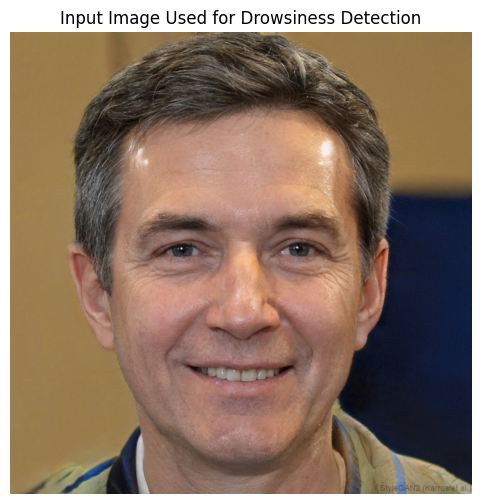

In [18]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("samples/face1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Input Image Used for Drowsiness Detection")

In [17]:
!python cli.py --image samples/face1.jpg


  Total people : 1
  Sleeping     : 0
  Awake        : 1
  ✓  All awake

